## *Proposition de workflow pour le process de données µSAXS*






#### **Etape 1: Conversion d'un fichier h5 en edf**

On utilise la méthode 'convert2edf' de la classe h5File_SWING, en précisant bien qu'on ne veut PAS moyenner les images (passer l'argument mean=False lors de l'instantiation de la classe).
Remarque: Dans le parser du format edf, le binning est par défaut 1. Par conséquent, la taille des pixels est mutlipliée par les paramètres de binning pendant la conversion en format edf.

In [27]:
%matplotlib widget
from saxsprocessor import SAXSProcessor
import glob
import os
import numpy as np
from matplotlib import pyplot as plt
import re
from utilities_SWING import *
import pandas as pd
from filereaders import h5File_SWING
from utilities import *

# Make pyfai warning silent (optional, but nicer output)
import logging, warnings

logging.getLogger("pyFAI").setLevel(logging.ERROR)
logging.getLogger("fabio").setLevel(logging.ERROR)

warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide",
    module="pyFAI"
)


On convertit le fichier et sa référence en fichiers edf qui correspondent aux differents points, grace à la fonction convert2edf

In [28]:

testfile = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00161_2026-02-06_09-24-37.nxs'
reference = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00148_2026-02-06_06-55-44.nxs'
edfpath='C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3/'
edfpathr='C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_r/'
file = h5File_SWING(testfile, mean = False) # we do not average data contained in this file, we force linescan (step_z=0)
filer = h5File_SWING(reference, mean = False)

# Convert mask from SWING mask (just to show it is possible)
#mask = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/mask_lacroix_jul24.txt'
#mask=file.convert_SWING_mask(maskfile=mask)

# as beamstop is missing on this mask, we use the following file:
mask = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/mask_pyfai.edf'


filer.convert2edf(outputdir=edfpathr)

# convert h5file to edf files
file.convert2edf(outputdir=edfpath)

print(f'Scan parameters: xstart = {file.position_x_start}, step x: {file.step_x}, zstart={file.position_z_start},step_z:{file.step_z}')


position moteur :
{'X_start': array([36.6002]), 'X_end': array([38.3502]), 'Z_start': array([39.4001]), 'Z_end': array([39.6003])}
step :
[0.04861111]
[0.04004]
[0.9679266  0.94129211 0.91000429 0.93426392 0.90742767 0.91749642
 0.96025856 0.98148761 0.9152112  0.9030519  0.95239529 0.90489335
 0.92183397 0.97359155 0.92878473 0.95645738 0.95349483 0.90081538
 0.92122297 0.92759174 0.99613369 0.92964583 0.91601678 0.9082107
 0.93345439 0.89758559 0.93378552 0.94472217 0.94444303 0.92571339
 0.94455993 0.92449746 0.89506643 0.94445187 0.99095034 0.91236202
 0.89975864 0.97056351 0.9268131  0.94596873 0.93925673 0.91323606
 0.94220963 0.91672747 0.93606101 0.90042982 0.92124153 0.91505542
 0.89987329 0.92503632 0.91601244 0.90696829 0.93422173 0.89338396
 0.91717515 0.89030621 0.9713751  0.92897083 0.90179384 0.88424059
 0.90308916 0.91756531 0.9364578  0.94316904 0.93005208 0.92713312
 0.94876848 0.96378565 0.95539117 0.9037807  0.92075465 0.91608798
 0.93250484 0.89320649 0.9454528  0.

In [29]:
# On peut regarder la transmission de fichier moyenné si jamais.
"""
proc = SAXSProcessor(instrument='SWING' ,autosubstract=True,file=testfile, mask=mask)
plot_transmission_map_from_singleh5(testfile, proc)"""

"\nproc = SAXSProcessor(instrument='SWING' ,autosubstract=True,file=testfile, mask=mask)\nplot_transmission_map_from_singleh5(testfile, proc)"

#### **Etape 2: Classement des fichiers individuels en liste**


In [ ]:
from saxsprocessor import SAXSProcessor
import glob
import os
import numpy as np
from matplotlib import pyplot as plt
import re


# retrieve the number of points from the h5file
file_filter = '*Img*.edf'  # be careful not to include the mask in this list
instrument = 'LGC'

# Establish a list of files
filelist = glob.glob(os.path.join(edfpath,file_filter))
filelistr = glob.glob(os.path.join(edfpathr,file_filter))

print(filelist)
print(filelistr)
# Sort the file list (we need to define a function)
# files are sorted by File_number.Img 


def parse_img(file):
    match = re.search(r'img_(\d+)_(\d+)', file, re.IGNORECASE)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None  # fichier non conforme

# On filtre : conserve seulement les fichiers valides
valid_files = [f for f in filelist if parse_img(f) is not None]
valid_filesr = [f for f in filelistr if parse_img(f) is not None]

# On trie uniquement les fichiers valides
sorted_files = sorted(valid_files, key=lambda f: parse_img(f))
sorted_filesr = sorted(valid_filesr, key=lambda f: parse_img(f))

print(sorted_files)
print(sorted_filesr)







['C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_0.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_1.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_10.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_11.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_12.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_13.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_14.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_15.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_16.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_File_161_Img_0_17.edf', 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_3\\S0001_M0099_Fi

Ici on peut extraire l'image 2d, le paramêtre d'ordre ainsi que les profils radiaux de n'importe quel point du fichier h5.

In [31]:
# je choisis d'extraire un point de référence situé au milieu de l'échantillon
reference = "C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/edf_files_r/E0000_M0087_File_148_Img_4_6.edf"



file1r = sorted_files[6]

proc = SAXSProcessor(file1r,reference_file= reference, autosubstract=False, mask=mask, instrument='LGC') # instrument is set to 'LGC' as we are dealing with edf files now.
# Use dedicated function to plot average SAXS image
q,Ir = proc.extract_radial_profile(azimuth=0, width=360)
proc.plot2d_vsq()

plt.figure()
plt.loglog(q, Ir, label='Average Radial Profile')
plt.xlabel('q (Å$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Average Radial Profile from SWING Data')
plt.legend()


# A automatiser avec le exel
AS = 8.38
diametre = 183
diametre_pd = 0.1421
L_pd=0.1569  
qvalue = 0.02690462


'''
S, orientation, results = compute_nematic_parameter(
    processor=proc,
    qvalue=qvalue,
    threshold=0.05,
    radius=diametre/2,
    L=AS*diametre,
    radius_pd=diametre_pd/2,
    L_pd=L_pd,
    plot=True,
    apply_mirror=False,
    verbose=True,
)'''






reference
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]
(1083, 1035)
(1083, 1035)


KeyboardInterrupt: 

Ici on fait la cartographie de notre fichier h5.

Attention à ne pas oublier de renseigner le nombre de colonne et de ligne de la carto ( à automatiser )

⚠️ WARNING: This function assumes the data correspond to a linescan.


[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   3 tasks      | elapsed:  4.0min
[Parallel(n_jobs=11)]: Done  10 tasks      | elapsed:  4.1min
[Parallel(n_jobs=11)]: Done  19 tasks      | elapsed:  8.0min
[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed: 11.8min
[Parallel(n_jobs=11)]: Done  39 tasks      | elapsed: 15.7min
[Parallel(n_jobs=11)]: Done  50 tasks      | elapsed: 19.6min
[Parallel(n_jobs=11)]: Done  63 tasks      | elapsed: 23.6min
[Parallel(n_jobs=11)]: Done  76 tasks      | elapsed: 31.1min
[Parallel(n_jobs=11)]: Done  91 tasks      | elapsed: 35.2min
[Parallel(n_jobs=11)]: Done 106 tasks      | elapsed: 41.0min
[Parallel(n_jobs=11)]: Done 123 tasks      | elapsed: 46.8min
[Parallel(n_jobs=11)]: Done 140 tasks      | elapsed: 54.3min
[Parallel(n_jobs=11)]: Done 159 tasks      | elapsed: 59.2min
[Parallel(n_jobs=11)]: Done 178 out of 180 | elapsed: 66.3min remaining:   44.6s
[Parallel(n_jobs=11)]: Done 180 out 

0 36.6002 39.4001
Avant R 0.9946138383681881
1 36.648811111111115 39.4001
Avant R 0.9823818587445439
2 36.69742222222222 39.4001
Avant R 0.9964847903681197
3 36.74603333333334 39.4001
Avant R 0.9965869140186899
4 36.794644444444444 39.4001
Avant R 0.869808815700374
5 36.84325555555556 39.4001
Avant R 0.9681310945953038
6 36.891866666666665 39.4001
Avant R 0.7239294854594871
7 36.94047777777778 39.4001
Avant R 0.975134393688634
8 36.98908888888889 39.4001
Avant R 0.986866085823114
9 37.0377 39.4001
Avant R 0.8325787182473922
10 37.086311111111115 39.4001
Avant R 0.9745013219148061
11 37.13492222222222 39.4001
Avant R 0.9911913848323334
12 37.18353333333334 39.4001
Avant R 0.9935588828637204
13 37.232144444444444 39.4001
Avant R 0.985010092201435
14 37.28075555555556 39.4001
Avant R 0.9352145031514726
15 37.329366666666665 39.4001
Avant R 0.8514292754119301
16 37.37797777777778 39.4001
Avant R 0.44817580827431347
17 37.42658888888889 39.4001
Avant R 0.8689212163979435
18 37.4752 39.4001


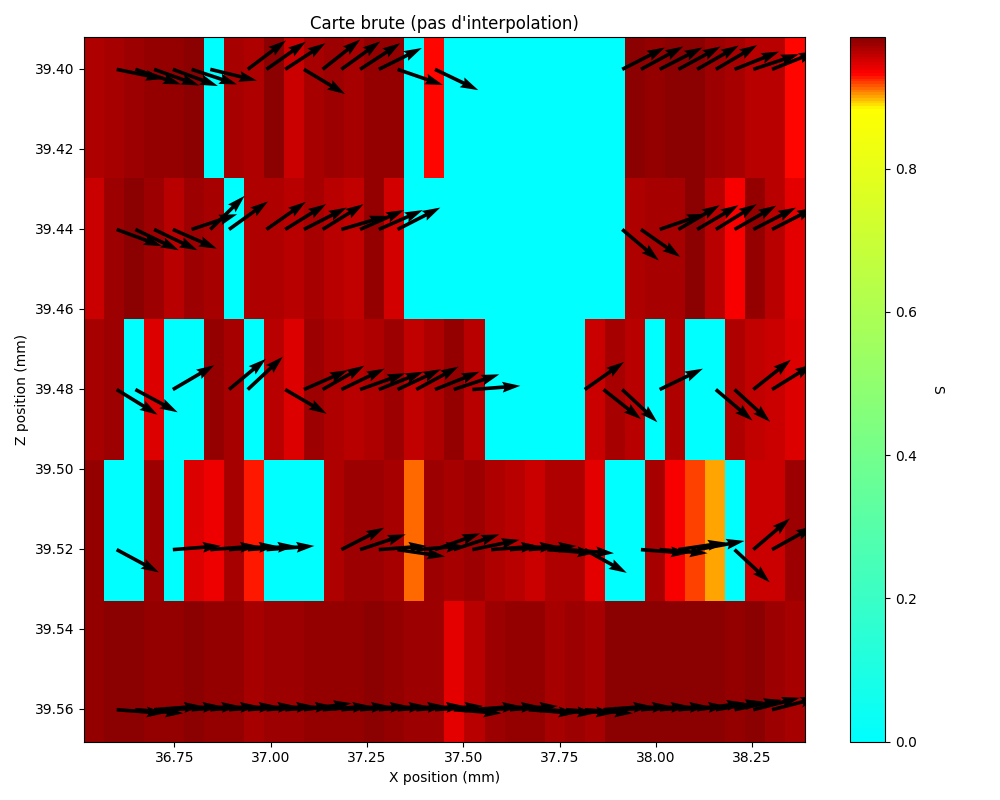

Carte 2 S [[0.96550526 0.96550526 0.96550526 0.96550526 0.96550526 0.96793426
  0.97303303 0.97303303 0.97903572 0.97903572 0.97802454 0.97802454
  0.98195538 0.98195538 0.         0.         0.96819803 0.96819803
  0.96407079 0.97933698 0.97933698 0.9538771  0.9538771  0.96962224
  0.96962224 0.97177366 0.97177366 0.97087189 0.97087189 0.9776964
  0.97630916 0.97630916 0.         0.         0.93067005 0.93067005
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.98107463
  0.97561113 0.97561113 0.98307228 0.98307228 0.98162388 0.98162388
  0.97464171 0.97464171 0.96892872 0.96892872 0.96258961 0.96258961
  0.96099646 0.93101532 0.93101532 0.93101532 0.93101532 0.93101532]
 [0.96550526 0.96550526 0.96550526 0.96550526 0.96550526 0.96793426
  0.97303303 0.97303303 0.97903572 0.97903572 0.97802454 0.97802454
  0.98195538 0.98195538 0.         0.         0.968198

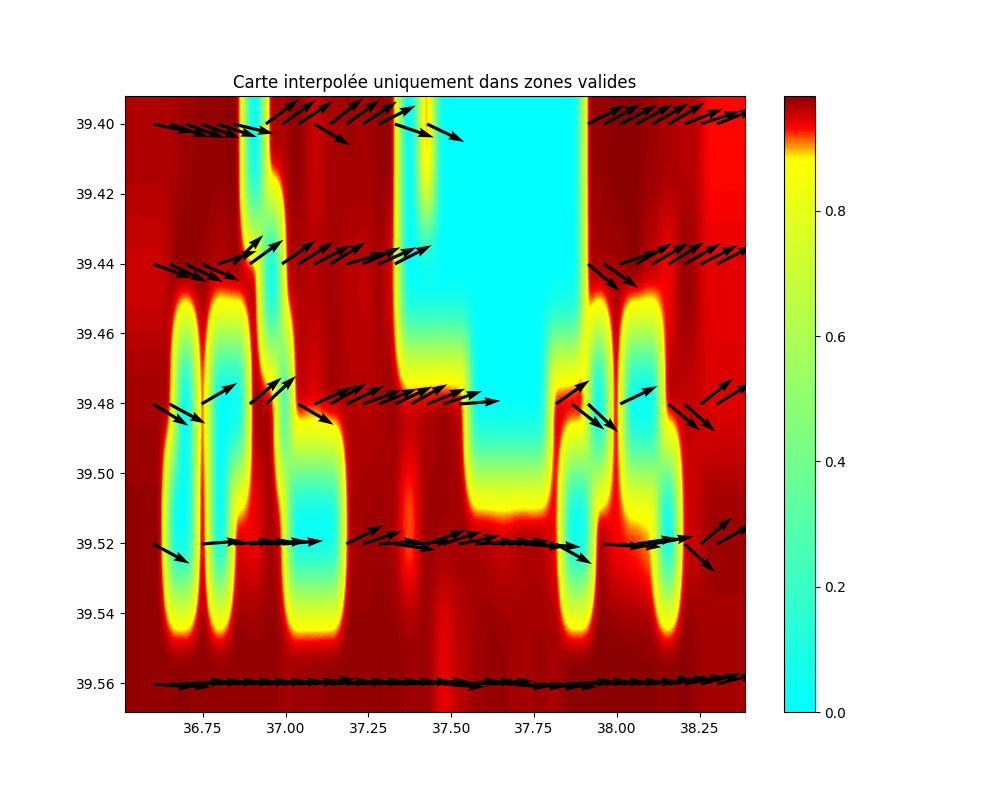

Carte 3 S [[0.96550526 0.96571833 0.9659314  ... 0.93627517 0.93364525 0.93101532]
 [0.96538917 0.96560224 0.96581531 ... 0.9363882  0.93375827 0.93112835]
 [0.96527309 0.96548616 0.96569923 ... 0.93650122 0.93387129 0.93124137]
 ...
 [0.97828584 0.97836685 0.97844786 ... 0.97103354 0.97075628 0.97047902]
 [0.97829737 0.97837837 0.97845938 ... 0.97100745 0.9707302  0.97045294]
 [0.97830889 0.9783899  0.9784709  ... 0.97098137 0.97070411 0.97042686]]
[[36.6002     36.64881111 36.69742222 36.74603333 36.79464444 36.84325556
  36.89186667 36.94047778 36.98908889 37.0377     37.08631111 37.13492222
  37.18353333 37.23214444 37.28075556 37.32936667 37.37797778 37.42658889
  37.4752     37.52381111 37.57242222 37.62103333 37.66964444 37.71825556
  37.76686667 37.81547778 37.86408889 37.9127     37.96131111 38.00992222
  38.05853333 38.10714444 38.15575556 38.20436667 38.25297778 38.30158889]
 [36.6002     36.64881111 36.69742222 36.74603333 36.79464444 36.84325556
  36.89186667 36.94047778 3

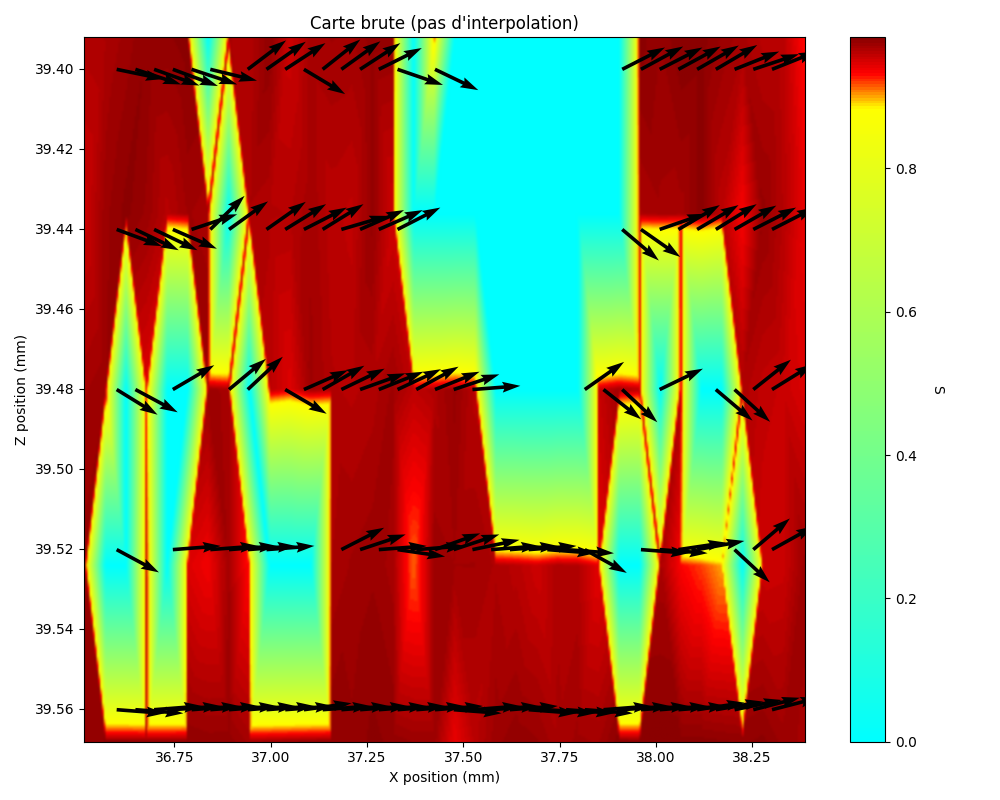

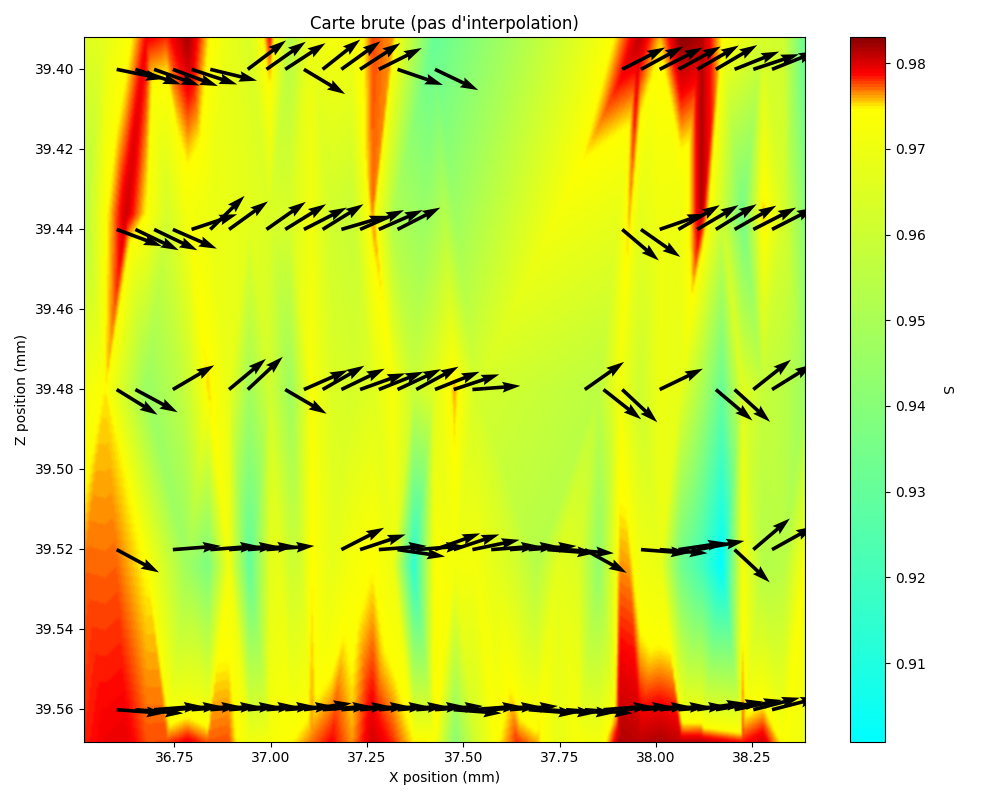

In [ ]:
from utilities_SWING import *
h5path='C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/'
#referencefile='path/to/reference/file'  # --- IGNORE ---
mask = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/mask_pyfai.edf'

AS = 8.38
diametre = 183
diametre_pd = 0.1421
L_pd=0.1569  
qvalue = 0.02690462

x_2d, z_2d, orientation_2d, S_2d, R2_2d = compute_nematic_order_assembly_SWING(
    h5path=h5path,
    mask=mask,
    filelist=sorted_files,
    autosubstract=False,
    reference_file = reference, 
    qvalue=qvalue,
    threshold=0.05,
    radius=diametre/2,
    L=AS*diametre,
    radius_pd=diametre_pd/2,
    L_pd=L_pd,
    plot=True,
    apply_mirror=False,
    verbose=True,
    nb_ligne=5,  # A integrer proprement dans la fonction
    nb_colonne=36
    )